In [0]:
    # NOTEBOOK : 04_Feature_Selection.ipynb
# OBJECTIF : Sélection statistique des features optimales
# Configuration Spark
#spark.conf.set("spark.sql.adaptive.enabled", "true")
#spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")
#print("Configuration chargée")
#print(f"Spark version : {spark.version}")

In [0]:
# ========================================
# IMPORTS
# ========================================
# PySpark
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.stat import Correlation, ChiSquareTest
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
# Statistiques
from scipy.stats import chi2_contingency, ttest_ind, f_oneway
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
# Configuration plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline
print("Imports réussis")

Imports réussis


In [0]:
# ========================================
# CHARGEMENT DONNÉES
# ========================================
# Source : Table Delta issue du Feature Engineering
# Adapter selon ton workspace
catalog = "workspace"
schema_name = "default"
table_name = "hospital_readmissions_features"
full_table_name = f"{catalog}.{schema_name}.{table_name}"
print(f"Chargement : {full_table_name}")
df = spark.table(full_table_name)
print(f"Dataset chargé : {df.count():,} lignes × {len(df.columns)} colonnes")
# Afficher colonnes
print("\nColonnes disponibles :")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col} ({df.schema[col].dataType})")

Chargement : workspace.default.hospital_readmissions_features
Dataset chargé : 69,750 lignes × 68 colonnes

Colonnes disponibles :
    1. patient_id (StringType())
    2. age (IntegerType())
    3. genre (StringType())
    4. diabete (BooleanType())
    5. hypertension (BooleanType())
    6. insuffisance_cardiaque (BooleanType())
    7. maladie_renale (BooleanType())
    8. cancer (BooleanType())
    9. depression (BooleanType())
   10. nb_comorbidites (IntegerType())
   11. charlson_index (IntegerType())
   12. diagnostic_principal (StringType())
   13. duree_sejour_jours (IntegerType())
   14. admission_urgence (BooleanType())
   15. service (StringType())
   16. date_admission (TimestampType())
   17. date_sortie (TimestampType())
   18. saison (StringType())
   19. proba_readmission (DoubleType())
   20. readmission_30j (BooleanType())
   21. nb_admissions_12mois (IntegerType())
   22. nb_medicaments (IntegerType())
   23. score_gravite_admission (IntegerType())
   24. support_soci

In [0]:
# ========================================
# IDENTIFICATION AUTOMATIQUE TYPES FEATURES
# ========================================
# WHY : Nécessaire pour appliquer les bons tests statistiques
# Variable cible
target_col = "readmission_30j"
# Colonnes à exclure (métadonnées, IDs, dates)
exclude_cols = [
    "patient_id", 
    "date_admission", "date_sortie",
    "date_admission_ts", "date_sortie_ts",
    target_col  # La cible ne peut pas être une feature
    ]
# Identification automatique des types
numeric_features = []
categorical_features = []
binary_features = []
for field in df.schema.fields:
    col_name = field.name
    col_type = field.dataType
    if col_name in exclude_cols:
        continue
    # Numériques
    if isinstance(col_type, (IntegerType, LongType, FloatType, DoubleType)):
        # Vérifier si binaire (0/1 uniquement)
        distinct_vals = df.select(col_name).distinct().count()
        if distinct_vals == 2:
            binary_features.append(col_name)
        else:
            numeric_features.append(col_name)
    # Booléens
    elif isinstance(col_type, BooleanType):
        binary_features.append(col_name) 
    # Catégorielles
    elif isinstance(col_type, StringType):
        distinct_vals = df.select(col_name).distinct().count()
        if distinct_vals <= 50:  # Seuil arbitraire
            categorical_features.append(col_name)
        else:
            print(f"{col_name} a {distinct_vals} catégories (trop élevé, exclus)")
# Rapport
print("="*60)
print("TYPOLOGIE DES FEATURES")
print("="*60)
print(f"\nNumériques ({len(numeric_features)}) :")
for feat in numeric_features:
    print(f"- {feat}")
print(f"\nCatégorielles ({len(categorical_features)}) :")
for feat in categorical_features:
    print(f"   - {feat}")
print(f"\nBinaires ({len(binary_features)}) :")
for feat in binary_features:
    print(f"   - {feat}")
print(f"\nTOTAL FEATURES : {len(numeric_features) + len(categorical_features) + len(binary_features)}")

TYPOLOGIE DES FEATURES

Numériques (22) :
- age
- nb_comorbidites
- charlson_index
- duree_sejour_jours
- proba_readmission
- nb_admissions_12mois
- nb_medicaments
- score_gravite_admission
- distance_hopital_km
- age_squared
- age_gender_interaction
- score_fragilite
- ratio_medic_comorb
- duree_sejour_log
- mois_admission
- saison_numeric
- support_social_numeric
- risque_cumule
- age_gravite_interaction
- age_comorbidites_interaction
- urgence_gravite
- risque_composite

Catégorielles (15) :
   - genre
   - diagnostic_principal
   - service
   - saison
   - support_social
   - age_category
   - distance_category
   - comorbidite_category
   - charlson_category
   - medicaments_category
   - duree_sejour_category
   - trimestre
   - admissions_category
   - gravite_category
   - diagnostic_groupe

Binaires (27) :
   - diabete
   - hypertension
   - insuffisance_cardiaque
   - maladie_renale
   - cancer
   - depression
   - admission_urgence
   - is_senior
   - zone_rurale
   - polypa

In [0]:
# ========================================
# FILTRE 1 : VARIANCE & CARDINALITÉ
# ========================================
# Objectif : Éliminer features non informatives
print("\n" + "="*60)
print("FILTRE 1 : VARIANCE & CARDINALITÉ")
print("="*60 + "\n")
features_to_remove = []
# 1.A - Features variance nulle/quasi-nulle (numériques)
print("VARIANCE NULLE (numériques) :")
for feat in numeric_features:
    std_dev = df.select(F.stddev(feat)).collect()[0][0]
    if std_dev is None or std_dev < 0.01:  # Seuil arbitraire
        print(f"{feat} : stddev = {std_dev}")
        features_to_remove.append(feat)
# 1.B - Features cardinalité trop faible (catégorielles)
print("\n CARDINALITÉ TROP FAIBLE (catégorielles) :")
for feat in categorical_features:
    n_unique = df.select(feat).distinct().count()
    if n_unique == 1:
        print(f"{feat} : {n_unique} valeur unique")
        features_to_remove.append(feat)
# 1.C - Features cardinalité trop élevée
print("\n CARDINALITÉ TROP ÉLEVÉE (catégorielles) :")
for feat in categorical_features:
    n_unique = df.select(feat).distinct().count()
    if n_unique > 30:  # Seuil : >30 catégories = trop fragmenté
        print(f"{feat} : {n_unique} catégories (exclus)")
        features_to_remove.append(feat)
# 1.D - Features binaires déséquilibrées (>99% d'une classe)
print("\nDÉSÉQUILIBRE EXTRÊME (binaires) :")
for feat in binary_features:
    value_counts = df.groupBy(feat).count().collect()
    if len(value_counts) == 2:
        total = sum([row['count'] for row in value_counts])
        max_count = max([row['count'] for row in value_counts])
        ratio = max_count / total
        if ratio > 0.99:
            print(f"{feat} : {ratio*100:.1f}% d'une classe")
            features_to_remove.append(feat)
# Supprimer doublons
features_to_remove = list(set(features_to_remove))
print(f"\nRÉSUMÉ FILTRE 1 :")
print(f"Features éliminées : {len(features_to_remove)}")
print(f"Features restantes : {len(numeric_features) + len(categorical_features) + len(binary_features) - len(features_to_remove)}")
# Mise à jour listes
numeric_features = [f for f in numeric_features if f not in features_to_remove]
categorical_features = [f for f in categorical_features if f not in features_to_remove]
binary_features = [f for f in binary_features if f not in features_to_remove]
print("\nFiltre 1 terminé")


FILTRE 1 : VARIANCE & CARDINALITÉ

VARIANCE NULLE (numériques) :

 CARDINALITÉ TROP FAIBLE (catégorielles) :
diagnostic_groupe : 1 valeur unique

 CARDINALITÉ TROP ÉLEVÉE (catégorielles) :

DÉSÉQUILIBRE EXTRÊME (binaires) :
cardio_renal : 99.5% d'une classe
trio_mortel : 99.9% d'une classe

RÉSUMÉ FILTRE 1 :
Features éliminées : 3
Features restantes : 61

Filtre 1 terminé


In [0]:
# ========================================
# FILTRE 2A : TESTS UNIVARIÉS - NUMÉRIQUES
# ========================================
# Test : t-test indépendant (comparaison moyennes entre readmission=True vs False)
# H0 : Pas de différence de moyenne entre les 2 groupes
# H1 : Différence significative
print("\n" + "="*60)
print("FILTRE 2A : T-TEST (Variables numériques)")
print("="*60 + "\n")
# Convertir en Pandas pour faciliter calculs (attention : ça marche si <1M lignes)
df_pd = df.select([target_col] + numeric_features).toPandas()
# Convertir cible en booléen
df_pd[target_col] = df_pd[target_col].astype(bool)
# Séparer groupes
group_readmit = df_pd[df_pd[target_col] == True]
group_no_readmit = df_pd[df_pd[target_col] == False]
# Tests
ttest_results = []
for feat in numeric_features:
    # Extraire valeurs (supprimer NaN)
    vals_readmit = group_readmit[feat].dropna()
    vals_no_readmit = group_no_readmit[feat].dropna()
    # t-test
    if len(vals_readmit) > 0 and len(vals_no_readmit) > 0:
        t_stat, p_value = ttest_ind(vals_readmit, vals_no_readmit, equal_var=False)
        # Différence moyennes
        mean_readmit = vals_readmit.mean()
        mean_no_readmit = vals_no_readmit.mean()
        mean_diff = mean_readmit - mean_no_readmit
        ttest_results.append({
            'feature': feat,
            't_statistic': t_stat,
            'p_value': p_value,
            'mean_readmit': mean_readmit,
            'mean_no_readmit': mean_no_readmit,
            'mean_difference': mean_diff,
            'significant': p_value < 0.05
        })
# DataFrame résultats
ttest_df = pd.DataFrame(ttest_results).sort_values('p_value')
print(ttest_df.to_string(index=False))
# Features à conserver
numeric_significant = ttest_df[ttest_df['significant']]['feature'].tolist()
print(f"\nRÉSUMÉ T-TEST :")
print(f"Features significatives (p<0.05) : {len(numeric_significant)}/{len(numeric_features)}")
print(f"Features éliminées : {len(numeric_features) - len(numeric_significant)}")
# Export pour rapport
ttest_df.to_csv("/Volumes/workspace/defaault/amdy_hopitalisation_data/ttest_results.csv", index=False)
print("\nRésultats exportés : /Volumes/workspace/default/amdy_hopitalisation_data/ttest_results.csv")



FILTRE 2A : T-TEST (Variables numériques)

                     feature  t_statistic       p_value  mean_readmit  mean_no_readmit  mean_difference  significant
                         age    46.754020  0.000000e+00     57.911993        46.965952        10.946040         True
age_comorbidites_interaction    39.440933  0.000000e+00     64.003065        40.343679        23.659386         True
     age_gravite_interaction    46.863711  0.000000e+00   1609.278247      1093.129099       516.149148         True
               risque_cumule    92.150005  0.000000e+00      1.888690         0.337273         1.551417         True
             score_fragilite    38.873884  0.000000e+00      1.377875         0.962772         0.415103         True
                 age_squared    48.530586  0.000000e+00   4071.399445      2904.263840      1167.135605         True
     score_gravite_admission    43.248905  0.000000e+00     22.511507        17.424889         5.086617         True
            risque_c

In [0]:
# ========================================
# FILTRE 2B : TESTS UNIVARIÉS - CATÉGORIELLES
# ========================================
# Test : Chi² d'indépendance
# H0 : Feature et cible sont indépendantes
# H1 : Association significative
print("\n" + "="*60)
print("FILTRE 2B : CHI² TEST (Variables catégorielles)")
print("="*60 + "\n")
chi2_results = []
for feat in categorical_features + binary_features:
    # Créer table de contingence
    contingency_table = df.groupBy(feat, target_col).count().toPandas()
    # Pivoter pour format matrice
    pivot = contingency_table.pivot(index=feat, columns=target_col, values='count').fillna(0)
    # Chi² test
    if pivot.shape[0] > 1 and pivot.shape[1] > 1:
        chi2_stat, p_value, dof, expected = chi2_contingency(pivot) 
        # Cramér's V (mesure force association)
        n = pivot.sum().sum()
        cramers_v = np.sqrt(chi2_stat / (n * (min(pivot.shape) - 1))) 
        chi2_results.append({
            'feature': feat,
            'chi2_statistic': chi2_stat,
            'p_value': p_value,
            'cramers_v': cramers_v,
            'significant': p_value < 0.05
        })
# DataFrame résultats
chi2_df = pd.DataFrame(chi2_results).sort_values('p_value')
print(chi2_df.to_string(index=False))
# Features à conserver
categorical_significant = chi2_df[chi2_df['significant']]['feature'].tolist()
print(f"\nRÉSUMÉ CHI² :")
print(f"   Features significatives (p<0.05) : {len(categorical_significant)}/{len(categorical_features) + len(binary_features)}")
print(f"   Features éliminées : {len(categorical_features) + len(binary_features) - len(categorical_significant)}")
# Export
chi2_df.to_csv("/Volumes/workspace/default/amdy_hopitalisation_data/chi2_results.csv", index=False)
print("\n Résultats exportés : /Volumes/workspace/default/amdy_hopitalisation_data/chi2_results.csv")


FILTRE 2B : CHI² TEST (Variables catégorielles)

                    feature  chi2_statistic       p_value  cramers_v  significant
hospitalisations_frequentes    10366.138271  0.000000e+00   0.385511         True
                  is_senior     2591.003008  0.000000e+00   0.192736         True
               age_category     2708.252030  0.000000e+00   0.197048         True
          charlson_category     2773.081471  0.000000e+00   0.199393         True
        admissions_category    30473.611169  0.000000e+00   0.660982         True
        readmission_recente    26108.235511  0.000000e+00   0.611810         True
       comorbidite_category     1101.502611 1.718200e-238   0.125667         True
 maladie_chronique_complexe     1000.239700 1.592810e-219   0.119751         True
               hypertension      762.802782 6.601564e-168   0.104576         True
           gravite_category      525.359940 8.308804e-115   0.086787         True
         admission_critique      456.636847 2.59

In [0]:
# ========================================
# MISE À JOUR POST-FILTRE 2
# ========================================
print("\n" + "="*60)
print("BILAN APRÈS FILTRE 2")
print("="*60 + "\n")
# Séparer catégorielles et binaires dans les résultats
categorical_significant_only = [f for f in categorical_significant if f in categorical_features]
binary_significant_only = [f for f in categorical_significant if f in binary_features]
# Mise à jour
numeric_features = numeric_significant
categorical_features = categorical_significant_only
binary_features = binary_significant_only
all_features = numeric_features + categorical_features + binary_features
print(f"Numériques : {len(numeric_features)}")
print(f"Catégorielles : {len(categorical_features)}")
print(f"Binaires : {len(binary_features)}")
print(f"\nTOTAL : {len(all_features)} features")
print("\nFiltre 2 terminé - Features univariément significatives retenues")


BILAN APRÈS FILTRE 2

Numériques : 16
Catégorielles : 8
Binaires : 18

TOTAL : 42 features

Filtre 2 terminé - Features univariément significatives retenues



FILTRE 3A : MATRICE CORRÉLATION

CORRÉLATION AVEC CIBLE (top 15) :
nb_admissions_12mois            0.654174
readmission_recente             0.611849
risque_cumule                   0.456981
hospitalisations_frequentes     0.385575
risque_composite                0.366615
proba_readmission               0.228252
charlson_index                  0.194554
is_senior                       0.192770
age_squared                     0.187514
age_gravite_interaction         0.183470
age                             0.175479
score_gravite_admission         0.165430
age_comorbidites_interaction    0.162530
score_fragilite                 0.160431
nb_comorbidites                 0.135780

Génération heatmap...


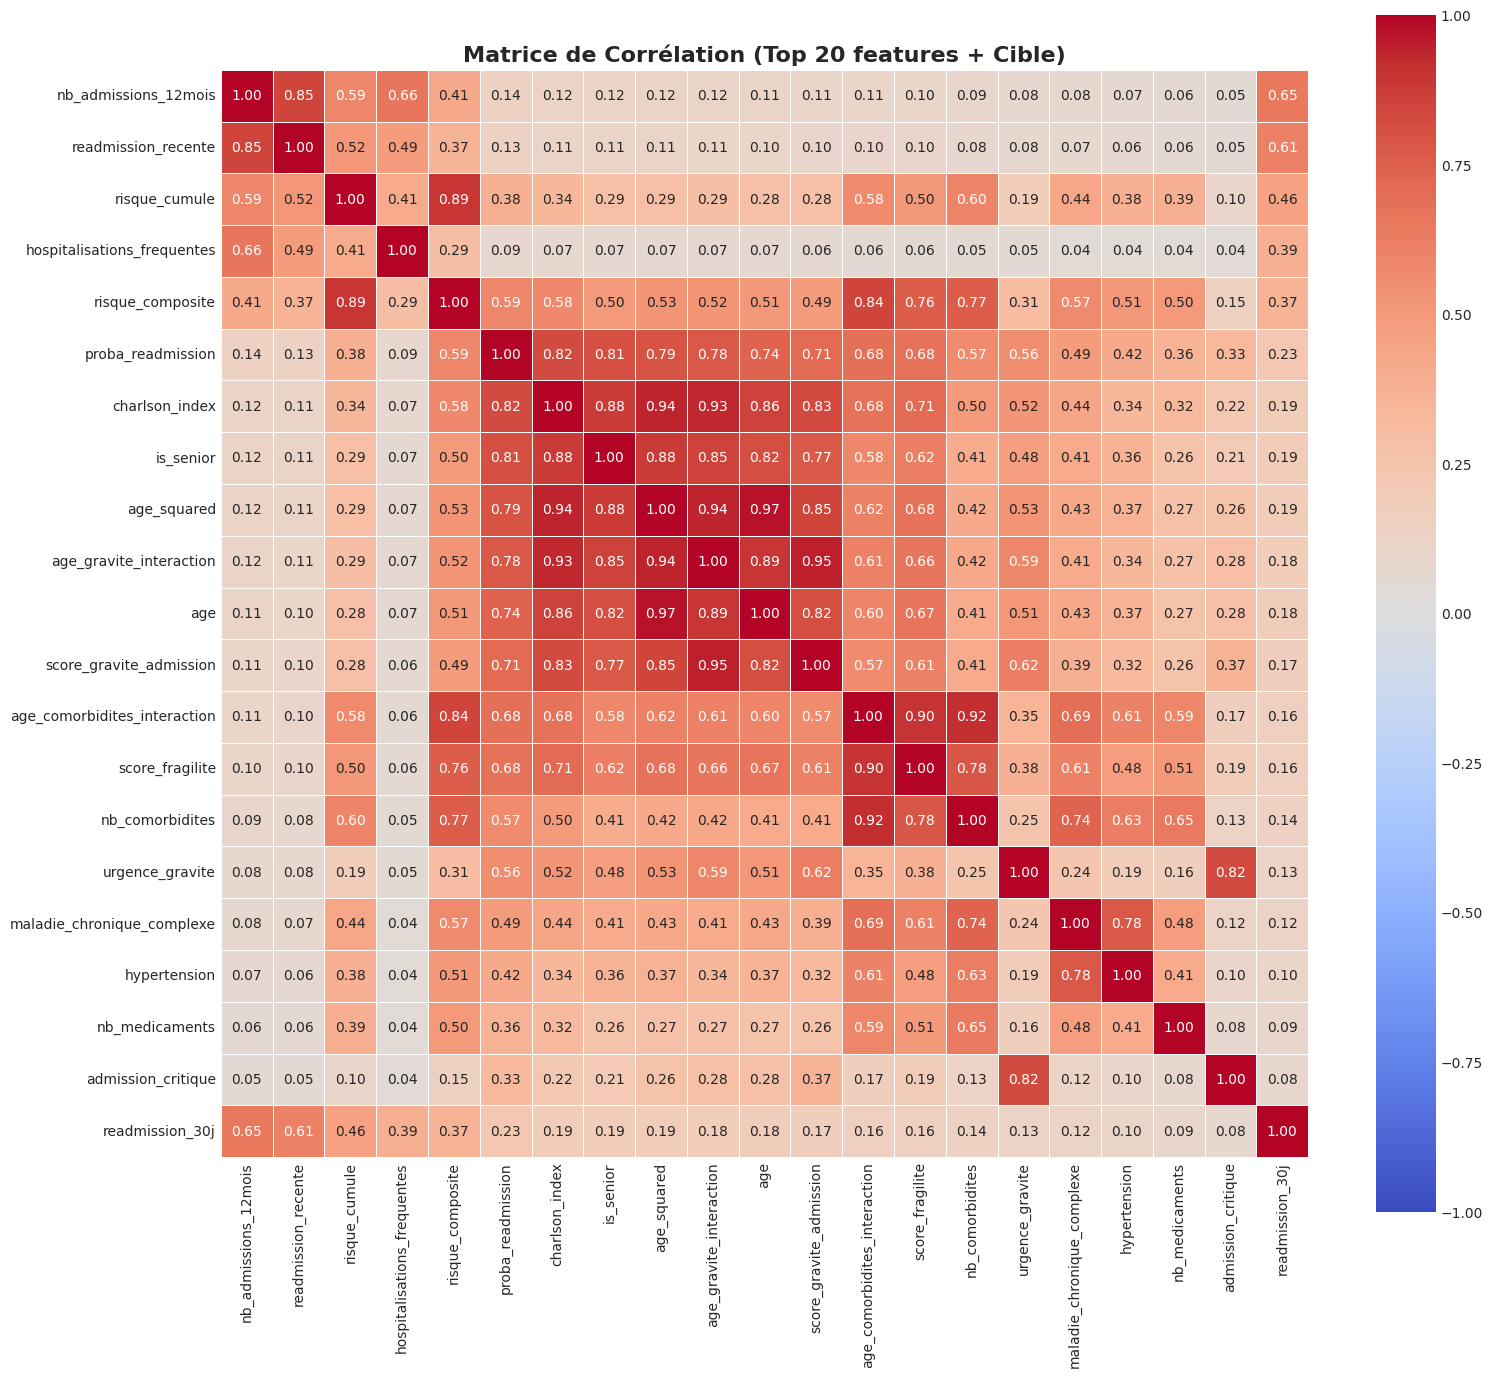

Heatmap sauvegardée : /Volumes/workspace/default/amdy_hopitalisation_data/correlation_matrix.png

PAIRES FORTEMENT CORRÉLÉES (>0.85) :
                    feature1                feature2  correlation               to_remove                      to_keep
                         age age_gravite_interaction     0.893115                     age      age_gravite_interaction
                         age             age_squared     0.969396                     age                  age_squared
                         age          charlson_index     0.858578                     age               charlson_index
age_comorbidites_interaction         score_fragilite     0.898682         score_fragilite age_comorbidites_interaction
age_comorbidites_interaction         nb_comorbidites     0.916581         nb_comorbidites age_comorbidites_interaction
     age_gravite_interaction             age_squared     0.944304 age_gravite_interaction                  age_squared
     age_gravite_interaction sco

In [0]:
# ========================================
# FILTRE 3A : MULTICOLINÉARITÉ - CORRÉLATION 
# ========================================
# Objectif : Détecter features redondantes (corrélation > 0.85)
print("\n" + "="*60)
print("FILTRE 3A : MATRICE CORRÉLATION")
print("="*60 + "\n")
# Convertir binaires en numériques pour calcul corrélation
df_corr = df.select([target_col] + numeric_features + binary_features)
# Conversion booléens → int
for col in binary_features:
    df_corr = df_corr.withColumn(col, F.col(col).cast("int"))
# Conversion cible
df_corr = df_corr.withColumn(target_col, F.col(target_col).cast("int"))
# Passer en Pandas (attention mémoire)
df_corr_pd = df_corr.toPandas()
# Matrice corrélation
corr_matrix = df_corr_pd.corr()
# Afficher corrélation avec cible
print("CORRÉLATION AVEC CIBLE (top 15) :")
target_corr = corr_matrix[target_col].drop(target_col).abs().sort_values(ascending=False)
print(target_corr.head(15).to_string())
# Visualisation heatmap (features numériques uniquement pour lisibilité)
print("\nGénération heatmap...")
# Sous-ensemble pour visualisation (top 20 features corrélées à cible)
top_features = target_corr.head(20).index.tolist()
corr_subset = corr_matrix.loc[top_features + [target_col], top_features + [target_col]]
plt.figure(figsize=(16, 14))
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Matrice de Corrélation (Top 20 features + Cible)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/Volumes/workspace/default/amdy_hopitalisation_data/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("Heatmap sauvegardée : /Volumes/workspace/default/amdy_hopitalisation_data/correlation_matrix.png")
# Détection paires fortement corrélées (> 0.85)
print("\nPAIRES FORTEMENT CORRÉLÉES (>0.85) :")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.85 and col1 != target_col and col2 != target_col:
            # Garder celle avec meilleure corrélation à cible
            corr_col1_target = abs(corr_matrix.loc[col1, target_col])
            corr_col2_target = abs(corr_matrix.loc[col2, target_col])
            to_remove = col2 if corr_col1_target >= corr_col2_target else col1
            to_keep = col1 if to_remove == col2 else col2    
            high_corr_pairs.append({
                'feature1': col1,
                'feature2': col2,
                'correlation': corr_val,
                'to_remove': to_remove,
                'to_keep': to_keep
            })
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df.to_string(index=False))
    # Liste features à supprimer
    features_to_remove_corr = high_corr_df['to_remove'].unique().tolist()
    print(f"\nFeatures à supprimer (multicolinéarité) : {len(features_to_remove_corr)}")
    for feat in features_to_remove_corr:
        print(f"   - {feat}")
else:
    features_to_remove_corr = []
    print("Aucune paire fortement corrélée détectée")
# Export
corr_matrix.to_csv("/Volumes/workspace/default/amdy_hopitalisation_data/correlation_matrix.csv")
print("\nMatrice exportée: /Volumes/workspace/default/amdy_hopitalisation_data/correlation_matrix.csv")

In [0]:
# ========================================
# FILTRE 3B : MULTICOLINÉARITÉ - VIF
# ========================================
# VIF > 10 → multicolinéarité sévère
# VIF 5-10 → multicolinéarité modérée
# VIF < 5 → acceptable
print("\n" + "="*60)
print("FILTRE 3B : VIF (Variance Inflation Factor)")
print("="*60 + "\n")
# Features après suppression corrélation
numeric_for_vif = [f for f in numeric_features if f not in features_to_remove_corr]
binary_for_vif = [f for f in binary_features if f not in features_to_remove_corr]
features_for_vif = numeric_for_vif + binary_for_vif
# Préparer données
df_vif = df.select(features_for_vif).toPandas()
# Remplacer NaN par médiane (VIF ne tolère pas les NaN)
df_vif = df_vif.fillna(df_vif.median())
# Calcul VIF itératif (supprimer features VIF>10 une par une)
print("Calcul VIF itératif (cela peut prendre 5-10 minutes)...\n")
vif_results = []
features_remaining = features_for_vif.copy()
iteration = 0
max_iterations = 20  # Sécurité pour éviter boucle infinie
while iteration < max_iterations:
    iteration += 1
    print(f"Itération {iteration} : {len(features_remaining)} features")
    # Calcul VIF pour features restantes
    vif_data = pd.DataFrame()
    vif_data["Feature"] = features_remaining
    # Calcul VIF pour chaque feature
    vif_values = []
    for i, feature in enumerate(features_remaining):
        try:
            vif = variance_inflation_factor(df_vif[features_remaining].values, i)
            vif_values.append(vif)
        except:
            # Si erreur (colonne constante, etc.), marquer comme inf
            vif_values.append(np.inf)
    vif_data["VIF"] = vif_values
    vif_data = vif_data.sort_values('VIF', ascending=False)
    # Afficher top 10 VIF
    print(vif_data.head(10).to_string(index=False))
    # Vérifier si VIF max > 10
    max_vif = vif_data['VIF'].max()
    if max_vif > 10:
        # Supprimer feature avec VIF max
        feature_to_remove = vif_data.iloc[0]['Feature']
        print(f"Suppression : {feature_to_remove} (VIF = {max_vif:.2f})")
        features_remaining.remove(feature_to_remove)
        vif_results.append({
            'iteration': iteration,
            'feature_removed': feature_to_remove,
            'vif_value': max_vif
        })
        print()
    else:
        print(f"\n Convergence atteinte : VIF max = {max_vif:.2f}")
        break
# Résultats finaux 
print("\n" + "="*60)
print("RÉSUMÉ VIF")
print("="*60)
final_vif = pd.DataFrame()
final_vif["Feature"] = features_remaining
final_vif["VIF"] = [variance_inflation_factor(df_vif[features_remaining].values, i) 
                    for i in range(len(features_remaining))]
final_vif = final_vif.sort_values('VIF', ascending=False)
print("\nVIF FINAUX (toutes features < 10) :")
print(final_vif.to_string(index=False))
# Features éliminées
if vif_results:
    vif_removed_df = pd.DataFrame(vif_results)
    print(f"\n Features supprimées (VIF>10) : {len(vif_results)}")
    print(vif_removed_df.to_string(index=False))
    features_to_remove_vif = vif_removed_df['feature_removed'].tolist()
else:
    features_to_remove_vif = []
    print("\nAucune feature supprimée (tous VIF < 10)")
# Export
final_vif.to_csv("/Volumes/workspace/default/amdy_hopitalisation_data/vif_results.csv", index=False)
print("\nVIF exportés : /Volumes/workspace/default/amdy_hopitalisation_data/vif_results.csv")
# Mise à jour listes features
all_features_to_remove_filter3 = list(set(features_to_remove_corr + features_to_remove_vif))
print(f"\nTOTAL FEATURES ÉLIMINÉES (Filtre 3) : {len(all_features_to_remove_filter3)}")


FILTRE 3B : VIF (Variance Inflation Factor)

Calcul VIF itératif (cela peut prendre 5-10 minutes)...

Itération 1 : 26 features
                     Feature  VIF
age_comorbidites_interaction  inf
               risque_cumule  inf
                      cancer  inf
              sur_medication  inf
           admission_urgence  inf
      insuffisance_cardiaque  inf
              maladie_renale  inf
              polymedication  inf
       poly_poly_interaction  inf
        diabete_hypertension  inf
Suppression : age_comorbidites_interaction (VIF = inf)

Itération 2 : 25 features
               Feature  VIF
         risque_cumule  inf
               diabete  inf
                cancer  inf
        sur_medication  inf
     admission_urgence  inf
insuffisance_cardiaque  inf
        maladie_renale  inf
        polymedication  inf
 poly_poly_interaction  inf
  diabete_hypertension  inf
Suppression : risque_cumule (VIF = inf)

Itération 3 : 24 features
               Feature  VIF
  nb_admissi

In [0]:
# ========================================
# MISE À JOUR POST-FILTRE 3
# ========================================
print("\n" + "="*60)
print("BILAN APRÈS FILTRE 3 (Multicolinéarité)")
print("="*60 + "\n")
# Supprimer features multicolinéaires
numeric_features = [f for f in numeric_features if f not in all_features_to_remove_filter3]
binary_features = [f for f in binary_features if f not in all_features_to_remove_filter3]
categorical_features = [f for f in categorical_features if f not in all_features_to_remove_filter3]
all_features = numeric_features + categorical_features + binary_features
print(f"Numériques : {len(numeric_features)}")
print(f"Catégorielles : {len(categorical_features)}")
print(f"Binaires : {len(binary_features)}")
print(f"\nTOTAL : {len(all_features)} features")
print("\nFiltre 3 terminé - Features non-colinéaires retenues")


BILAN APRÈS FILTRE 3 (Multicolinéarité)

Numériques : 0
Catégorielles : 8
Binaires : 7

TOTAL : 15 features

Filtre 3 terminé - Features non-colinéaires retenues


In [0]:
# ========================================
# FILTRE 4A : PRÉPARATION POUR RANDOM FOREST
# ========================================
# WHY : Random Forest nécessite toutes features numériques
#  → Encoder catégorielles, assembler vecteurs
print("\n" + "=" *60)
print("FILTRE 4 : FEATURE IMPORTANCE (Random Forest)")
print("="*60 + "\n")
print("Étape 1/3 : Préparation des données...")
# 1. Encoder variables catégorielles (One-Hot Encoding)
stages = []
encoded_cols = []
for cat_col in categorical_features:
    # StringIndexer : catégorie → index numérique
    indexer = StringIndexer(inputCol=cat_col, 
                           outputCol=f"{cat_col}_indexed",
                           handleInvalid="keep")
    # OneHotEncoder : index → vecteur binaire
    encoder = OneHotEncoder(inputCols=[f"{cat_col}_indexed"],
                           outputCols=[f"{cat_col}_encoded"],
                           handleInvalid="keep")
    stages.extend([indexer, encoder])
    encoded_cols.append(f"{cat_col}_encoded")
# 2. Convertir binaires en numériques
df_ml = df.select([target_col] + all_features)
for bin_col in binary_features:
    df_ml = df_ml.withColumn(bin_col, F.col(bin_col).cast("double"))
# 3. Appliquer pipeline encodage
if stages:
    pipeline_encoding = Pipeline(stages=stages)
    df_ml = pipeline_encoding.fit(df_ml).transform(df_ml)
# 4. Assembler toutes features en un seul vecteur
feature_cols = numeric_features + binary_features + encoded_cols
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="skip"  # Ignore lignes avec NaN
)
df_ml = assembler.transform(df_ml)
# 5. Convertir cible en numérique (0/1)
df_ml = df_ml.withColumn("label", F.col(target_col).cast("double"))
# 6. Split train/test (80/20)
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)
print(f"Données préparées :")
print(f"Train : {train_df.count():,} lignes")
print(f"Test : {test_df.count():,} lignes")
print(f"Features assemblées : {len(feature_cols)}")


FILTRE 4 : FEATURE IMPORTANCE (Random Forest)

Étape 1/3 : Préparation des données...
Données préparées :
Train : 55,652 lignes
Test : 14,098 lignes
Features assemblées : 15


In [0]:
# ========================================
# FILTRE 4B : ENTRAÎNEMENT RANDOM FOREST
# ========================================
print("\nÉtape 2/3 : Entraînement Random Forest ")
# Configuration Random Forest
# WHY : Hyperparamètres choisis pour équilibrer performance et vitesse
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    predictionCol="prediction",
    numTrees=100,              # Nombre d'arbres (plus = meilleur mais plus lent)
    maxDepth=10,               # Profondeur max (évite overfitting)
    minInstancesPerNode=50,    # Min observations par nœud
    featureSubsetStrategy="sqrt",  # Nombre features par split
    seed=42
)
# Entraînement
print("Entraînement en cours...")
rf_model = rf.fit(train_df)
print("Modèle entraîné")
# Évaluation rapide sur test
from pyspark.ml.evaluation import BinaryClassificationEvaluator
predictions = rf_model.transform(test_df)
evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
auc = evaluator.evaluate(predictions)
print(f"\nPerformance modèle (test set) :")
print(f"   AUC-ROC : {auc:.4f}")
if auc < 0.65:
    print("Performance faible - vérifier qualité features")
elif auc < 0.75:
    print("Performance acceptable")
else:
    print("Performance excellente")


Étape 2/3 : Entraînement Random Forest...
   (Cela peut prendre 5-15 minutes selon la taille du dataset)

Entraînement en cours...
Modèle entraîné

Performance modèle (test set) :
   AUC-ROC : 0.9181
Performance excellente



 Étape 3/3 : Extraction Feature Importance...

DIAGNOSTIC DÉSALIGNEMENT

feature_cols (défini dans CELLULE 12) :
Nombre d'éléments : 15
Premiers 5 : ['polymedication', 'maladie_renale', 'insuffisance_cardiaque', 'admission_urgence', 'sur_medication']

featureImportances (du modèle RF) :
 Nombre d'éléments : 52
Premières 5 valeurs : [0.00013574 0.00037372 0.0002169  0.0013681  0.00020147]

Modèle RF :
numFeatures (attendu par le modèle) : 52

PROBLÈME DÉTECTÉ : DÉSALIGNEMENT
   feature_cols : 15 éléments
   feature_importances : 52 éléments
   Différence : 37

ANALYSE DES CAUSES :

Features encodées (One-Hot) : 8
Exemples : ['age_category_encoded', 'charlson_category_encoded', 'admissions_category_encoded']
 One-Hot crée PLUSIEURS colonnes par feature catégorielle

Vérification cohérence VectorAssembler :
Colonnes assemblées (feature_cols) : 15
Features attendues par modèle : 52

APPLICATION SOLUTION : Récupération noms depuis VectorAssembler


SOLUTION : Reconstruction feature_cols

R

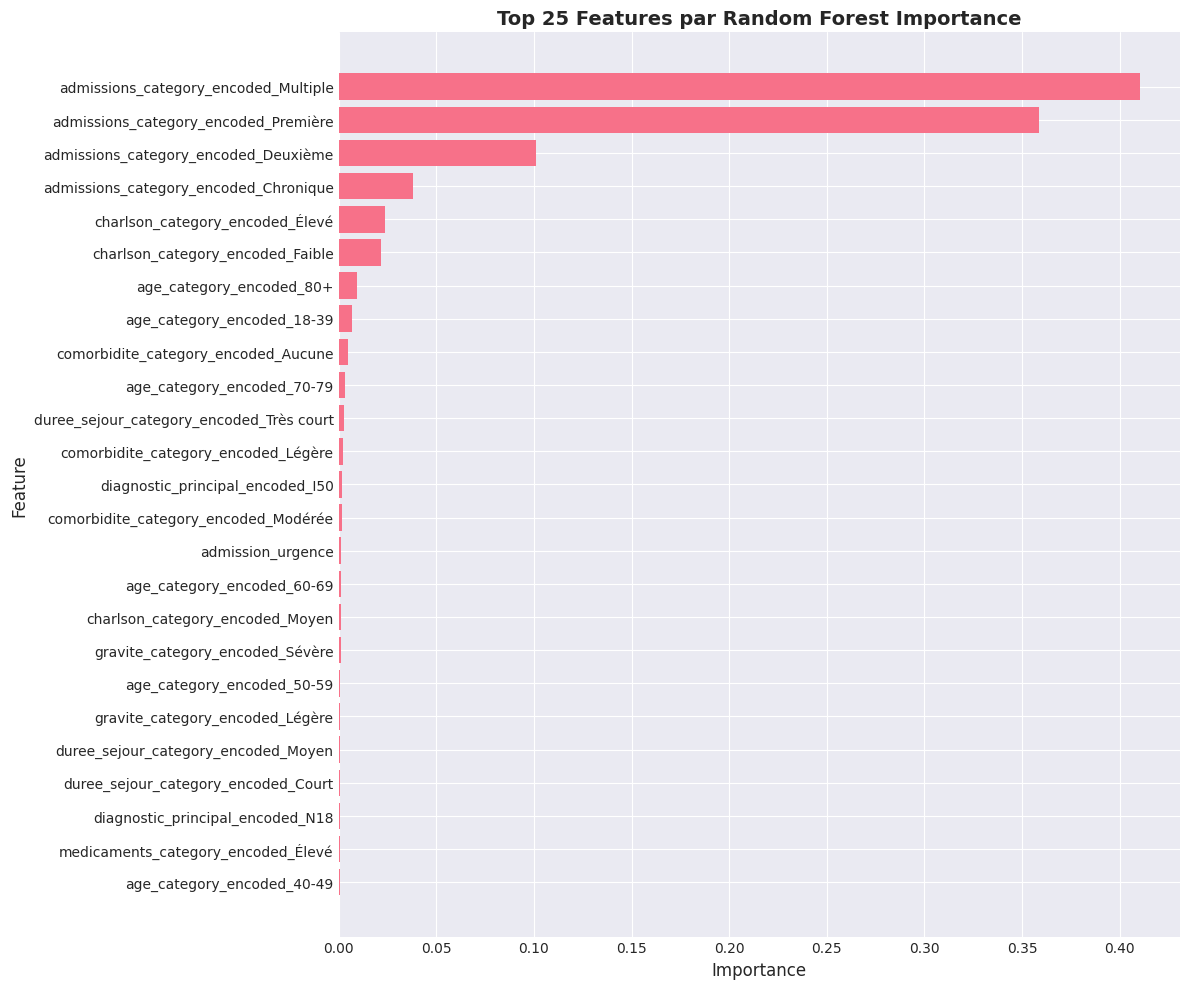

Graphique 1 sauvegardé : /Volumes/workspace/default/amdy_hopitalisation_data/feature_importance.png

ANALYSE IMPORTANCE CUMULÉE :
Features pour 95% importance : 6
Features pour 90% importance : 4
Features pour 80% importance : 3


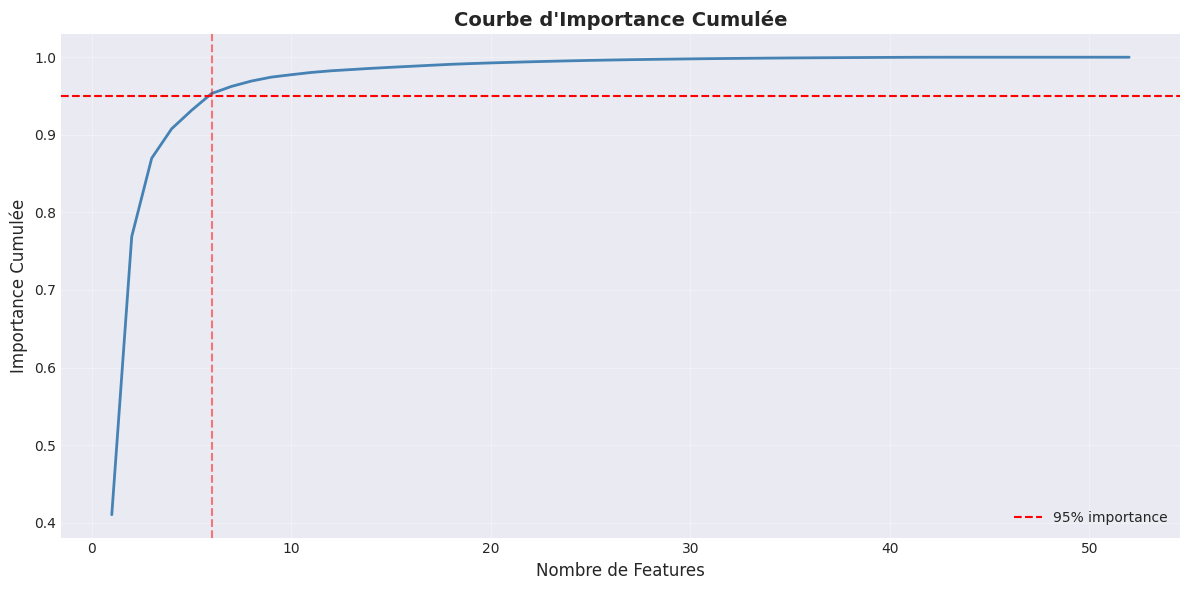

Graphique 2 sauvegardé : /Volumes/workspace/default/amdy_hopitalisation_data/cumulative_importance.png

Importances exportées : /Volumes/workspace/default/amdy_hopitalisation_data/feature_importance.csv

CELLULE 14 TERMINÉE AVEC SUCCÈS


In [0]:
# ========================================
# FILTRE 4C : FEATURE IMPORTANCE (VERSION CORRIGÉE)
# ========================================
print("\n Étape 3/3 : Extraction Feature Importance \n")
# ========================================
# DIAGNOSTIC PRÉALABLE
# ========================================
print("DIAGNOSTIC DÉSALIGNEMENT\n")
# 1. Vérifier feature_cols
if 'feature_cols' not in locals():
    print("ERREUR : feature_cols non défini")
    print("Ré-exécuter CELLULE 12 (Préparation ML)")
    raise Exception("feature_cols manquant")
print(f"feature_cols (défini dans CELLULE 12) :")
print(f"Nombre d'éléments : {len(feature_cols)}")
print(f"Premiers 5 : {feature_cols[:5]}")
# 2. Vérifier featureImportances du modèle
if not hasattr(rf_model, 'featureImportances'):

    raise Exception("featureImportances non disponible")
feature_importances = rf_model.featureImportances.toArray()
print(f"\nfeatureImportances (du modèle RF) :")
print(f" Nombre d'éléments : {len(feature_importances)}")
print(f"Premières 5 valeurs : {feature_importances[:5]}")
# 3. Vérifier numFeatures du modèle
print(f"\nModèle RF :")
print(f"numFeatures (attendu par le modèle) : {rf_model.numFeatures}")
# ========================================
# IDENTIFICATION DU PROBLÈME
# ========================================
print("\n" + "="*60)
if len(feature_cols) != len(feature_importances):
    print("PROBLÈME DÉTECTÉ : DÉSALIGNEMENT")
    print("="*60)
    print(f"   feature_cols : {len(feature_cols)} éléments")
    print(f"   feature_importances : {len(feature_importances)} éléments")
    print(f"   Différence : {abs(len(feature_cols) - len(feature_importances))}")
    # Analyser la cause
    print("\nANALYSE DES CAUSES :\n")
    # Cas 1 : One-Hot Encoding a créé plus de colonnes
    encoded_features = [col for col in feature_cols if '_encoded' in col]
    print(f"Features encodées (One-Hot) : {len(encoded_features)}")
    if encoded_features:
        print(f"Exemples : {encoded_features[:3]}")
        print(" One-Hot crée PLUSIEURS colonnes par feature catégorielle")
    # Cas 2 : Problème dans VectorAssembler
    print(f"\nVérification cohérence VectorAssembler :")
    print(f"Colonnes assemblées (feature_cols) : {len(feature_cols)}")
    print(f"Features attendues par modèle : {rf_model.numFeatures}")
    # SOLUTION : Récupérer les noms réels depuis le VectorAssembler
    print("\nAPPLICATION SOLUTION : Récupération noms depuis VectorAssembler\n")
    # Retrouver l'assembler depuis la cellule 12
    # On va recréer la liste feature_cols CORRECTE
else:
    print("PAS DE DÉSALIGNEMENT")
    print("="*60)
    print(f"feature_cols et feature_importances : {len(feature_cols)} éléments")
# ==========================================================
# SOLUTION 1 : RECONSTRUCTION FEATURE_COLS
# ==========================================================
print("\nSOLUTION : Reconstruction feature_cols\n")
# Méthode : Récupérer exactement les colonnes utilisées par VectorAssembler
# Recharger les listes de features depuis les variables globales
try:
    # Ces variables doivent exister depuis les cellules précédentes
    print("Reconstruction à partir des listes globales :\n")
    # Features numériques (toujours 1 colonne = 1 feature)
    numeric_for_ml = [f for f in numeric_features if f not in all_features_to_remove_filter3]
    print(f"   Numériques : {len(numeric_for_ml)}")
    # Features binaires (1 colonne = 1 feature)
    binary_for_ml = [f for f in binary_features if f not in all_features_to_remove_filter3]
    print(f"   Binaires : {len(binary_for_ml)}")
    # Features catégorielles ENCODÉES (1 feature catégorielle → N colonnes One-Hot)
    categorical_for_ml = [f for f in categorical_features if f not in all_features_to_remove_filter3]
    print(f"   Catégorielles (originales) : {len(categorical_for_ml)}")
    # Calculer nombre RÉEL de colonnes après One-Hot
    # Pour cela, on doit regarder dans df_ml
    encoded_cols_actual = []
    for cat_col in categorical_for_ml:
        encoded_col_name = f"{cat_col}_encoded"
        if encoded_col_name in df_ml.columns:
            # Récupérer la dimension du vecteur One-Hot
            # (c'est un vecteur, pas un scalaire)
            encoded_cols_actual.append(encoded_col_name)
    print(f"   Catégorielles encodées : {len(encoded_cols_actual)} colonnes de vecteurs")
    # PROBLÈME : Les vecteurs One-Hot ne sont PAS des scalaires
    # Chaque vecteur contribue à PLUSIEURS dimensions dans le VectorAssembler
    print("\nCOMPLEXITÉ : One-Hot Encoding crée des vecteurs multi-dimensionnels")
    print("   → 1 feature catégorielle → 1 vecteur → K dimensions (K = nb catégories - 1)")
    # SOLUTION DÉFINITIVE : Utiliser les métadonnées du VectorAssembler
    print("\nSOLUTION DÉFINITIVE : Métadonnées VectorAssembler\n")
    # Le VectorAssembler stocke les métadonnées dans le schéma
    # On va les extraire depuis df_ml
    from pyspark.ml.linalg import VectorUDT
    # Récupérer metadata du vecteur 'features'
    features_metadata = df_ml.schema["features"].metadata
    if "ml_attr" in features_metadata:
        attrs = features_metadata["ml_attr"]["attrs"]
        # Extraire tous les noms de features
        feature_names_reconstructed = []
        # Parcourir attributes (numeric, binary, nominal)
        for attr_type in ["numeric", "binary", "nominal"]:
            if attr_type in attrs:
                for attr in attrs[attr_type]:
                    if "name" in attr:
                        feature_names_reconstructed.append(attr["name"])
                    else:
                        # Fallback : utiliser idx
                        feature_names_reconstructed.append(f"feature_{attr['idx']}")
        print(f"Reconstruction réussie : {len(feature_names_reconstructed)} features")
        print(f" Premières 10 : {feature_names_reconstructed[:10]}")
        # Vérifier longueur
        if len(feature_names_reconstructed) == len(feature_importances):
            print(f"\nALIGNEMENT PARFAIT : {len(feature_names_reconstructed)} == {len(feature_importances)}")
            feature_cols_corrected = feature_names_reconstructed
        else:
            print(f"\nDésalignement persiste : {len(feature_names_reconstructed)} vs {len(feature_importances)}")
            # Fallback : noms génériques
            feature_cols_corrected = [f"feature_{i}" for i in range(len(feature_importances))]
    else:
        print("Métadonnées non disponibles, utilisation noms génériques")
        feature_cols_corrected = [f"feature_{i}" for i in range(len(feature_importances))]
except Exception as e:
    print(f"\nErreur reconstruction : {e}")
    print("Fallback : noms génériques")
    feature_cols_corrected = [f"feature_{i}" for i in range(len(feature_importances))]
# ========================================
# CRÉATION DATAFRAME IMPORTANCE
# ========================================
print("\nCRÉATION DATAFRAME IMPORTANCE\n")
importance_df = pd.DataFrame({
    'feature': feature_cols_corrected,
    'importance': feature_importances
}).sort_values('importance', ascending=False)
print(f"importance_df créé : {len(importance_df)} lignes")
# Afficher top 30
print("\nTOP 30 FEATURES PAR IMPORTANCE :")
print(importance_df.head(30).to_string(index=False))
# ========================================
# VISUALISATION
# ========================================
print("\nGÉNÉRATION GRAPHIQUES\n")
# Graphique 1 : Top features
plt.figure(figsize=(12, 10))
top_n = 25
top_features = importance_df.head(top_n)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n} Features par Random Forest Importance', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
# Sauvegarder
save_path_1 = '/Volumes/workspace/default/amdy_hopitalisation_data/feature_importance.png'
plt.savefig(save_path_1, dpi=300, bbox_inches='tight')
plt.show()
print(f"Graphique 1 sauvegardé : {save_path_1}")
# Calculer importance cumulée
importance_df['cumulative_importance'] = importance_df['importance'].cumsum()
# Trouver nombre features pour différents seuils
threshold_95 = 0.95
threshold_90 = 0.90
threshold_80 = 0.80
n_features_95 = len(importance_df[importance_df['cumulative_importance'] <= threshold_95]) + 1
n_features_90 = len(importance_df[importance_df['cumulative_importance'] <= threshold_90]) + 1
n_features_80 = len(importance_df[importance_df['cumulative_importance'] <= threshold_80]) + 1
print(f"\nANALYSE IMPORTANCE CUMULÉE :")
print(f"Features pour 95% importance : {n_features_95}")
print(f"Features pour 90% importance : {n_features_90}")
print(f"Features pour 80% importance : {n_features_80}")
# Graphique 2 : Importance cumulée
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(importance_df) + 1), 
         importance_df['cumulative_importance'].values,
         linewidth=2, color='steelblue')
plt.axhline(y=0.95, color='r', linestyle='--', linewidth=1.5, label='95% 
importance')
plt.axvline(x=n_features_95, color='r', linestyle='--', linewidth=1.5, alpha=0.5)
plt.xlabel('Nombre de Features', fontsize=12)
plt.ylabel('Importance Cumulée', fontsize=12)
plt.title('Courbe d\'Importance Cumulée', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Sauvegarder
save_path_2 = '/Volumes/workspace/default/amdy_hopitalisation_data/cumulative_importance.png'
plt.savefig(save_path_2, dpi=300, bbox_inches='tight')
plt.show()
print(f"Graphique 2 sauvegardé : {save_path_2}")
# Export CSV
csv_path = "/Volumes/workspace/default/amdy_hopitalisation_data/feature_importance.csv"
importance_df.to_csv(csv_path, index=False)
print(f"\nImportances exportées : {csv_path}")
print("\n" + "="*60)
print("CELLULE 14 TERMINÉE AVEC SUCCÈS")
print("="*60)

In [0]:
# ========================================
# SÉLECTION FINALE DES FEATURES
# ========================================
# STRATÉGIE : Garder top N features par importance
#             Ou seuil d'importance cumulée
print("\n" + "="*60)
print("SÉLECTION FINALE DES FEATURES")
print("="*60 + "\n")
# OPTION 1 : Top N features (recommandé : 25-30)
top_n_final = 30
selected_features_option1 = importance_df.head(top_n_final)['feature'].tolist()
# OPTION 2 : Seuil importance cumulée (ex: 95%)
threshold = 0.95
selected_features_option2 = importance_df[
    importance_df['cumulative_importance'] <= threshold
]['feature'].tolist()
# DÉCISION : Choisir l'approche
print("OPTIONS DE SÉLECTION :")
print(f"\nTop {top_n_final} features :")
print(f"Nombre : {len(selected_features_option1)}")
print(f"Importance cumulée : {importance_df.head(top_n_final)['importance'].sum():.2%}")
print(f"\nSeuil {threshold*100}% importance cumulée :")
print(f"Nombre : {len(selected_features_option2)}")
# CHOIX : Option 1 (plus stable)
selected_features = selected_features_option1
print(f"\nCHOIX : Option 1 - Top {top_n_final} features")
# Afficher liste finale
print(f"\nFEATURES SÉLECTIONNÉES ({len(selected_features)}) :")
for i, feat in enumerate(selected_features, 1):
    importance = importance_df[importance_df['feature'] == feat]['importance'].values[0]
    print(f"   {i:2d}. {feat:40s} (importance: {importance:.4f})")
# Retrouver noms originaux (sans suffixes _encoded)
original_features = []
for feat in selected_features:
    if "_encoded" in feat:
        original = feat.replace("_encoded", "")
        original_features.append(original)
    else:
        original_features.append(feat)
original_features = list(set(original_features))  # Supprimer doublons
print(f"\nFEATURES ORIGINALES À CONSERVER ({len(original_features)}) :")
for feat in sorted(original_features):
    print(f" - {feat}")


SÉLECTION FINALE DES FEATURES

OPTIONS DE SÉLECTION :

Top 30 features :
Nombre : 30
Importance cumulée : 99.78%

Seuil 95.0% importance cumulée :
Nombre : 5

CHOIX : Option 1 - Top 30 features

FEATURES SÉLECTIONNÉES (30) :
    1. admissions_category_encoded_Multiple     (importance: 0.4103)
    2. admissions_category_encoded_Première     (importance: 0.3585)
    3. admissions_category_encoded_Deuxième     (importance: 0.1010)
    4. admissions_category_encoded_Chronique    (importance: 0.0380)
    5. charlson_category_encoded_Élevé          (importance: 0.0238)
    6. charlson_category_encoded_Faible         (importance: 0.0216)
    7. age_category_encoded_80+                 (importance: 0.0092)
    8. age_category_encoded_18-39               (importance: 0.0069)
    9. comorbidite_category_encoded_Aucune      (importance: 0.0051)
   10. age_category_encoded_70-79               (importance: 0.0031)
   11. duree_sejour_category_encoded_Très court (importance: 0.0029)
   12. comorbid

In [0]:
# ========================================
# CELLULE 16 : CRÉATION DATASET FINAL 
# ========================================
print("\n" + "="*60)
print("CRÉATION DATASET FINAL POUR MODÉLISATION")
print("="*60 + "\n")
# ========================================
# ÉTAPE 1 : DIAGNOSTIC COLONNES
# ========================================
print("DIAGNOSTIC COLONNES\n")
print(f" Features sélectionnées (original_features) : {len(original_features)}")
print(f"Premières 10 : {original_features[:10]}")
print(f"\n Colonnes disponibles dans df (table source) : {len(df.columns)}")
print(f"Premières 10 : {df.columns[:10]}")
# ========================================
# ÉTAPE 2 : NETTOYAGE NOMS FEATURES
# ========================================
print("\n NETTOYAGE NOMS FEATURES\n")
# Supprimer suffixes One-Hot Encoding (_encoded)
# Ces colonnes n'existent PAS dans df original
original_features_cleaned = []
for feat in original_features:
    # Cas 1 : Feature encodée (nom_feature_encoded)
    if "_encoded" in feat:
        # Retrouver nom original (avant encodage)
        original_name = feat.replace("_encoded", "")
        # Vérifier si existe dans df
        if original_name in df.columns:
            if original_name not in original_features_cleaned:
                original_features_cleaned.append(original_name)
                print(f" {feat} → {original_name}")
        else:
            print(f"{feat} → {original_name} (n'existe pas dans df, ignoré)")
    # Cas 2 : Nom avec catégorie One-Hot (ex: duree_sejour_category_Moyen)
    # Pattern : nom_feature_CategorieValue 
    elif any(keyword in feat for keyword in ["_Très", "_Court", "_Moyen", "_Long", "_Faible", "_Élevé", "_Sévère"]):
        # C'est une colonne créée par One-Hot, retrouver base
        # Exemple : duree_sejour_category_Moyen → duree_sejour_category
        # Stratégie : chercher le préfixe qui existe dans df
        parts = feat.split("_")
        for i in range(len(parts), 0, -1):
            potential_base = "_".join(parts[:i])
            if potential_base in df.columns:
                if potential_base not in original_features_cleaned:
                    original_features_cleaned.append(potential_base)
                    print(f"{feat} → {potential_base} (colonne One-Hot)")
                break
        else:
            print(f"{feat} → base non trouvée (ignoré)")
    # Cas 3 : Nom standard (existe tel quel dans df)
    elif feat in df.columns:
        if feat not in original_features_cleaned:
            original_features_cleaned.append(feat)
            print(f"{feat} (colonne directe)")
    else:
print(f"{feat} (n'existe pas dans df, ignoré)")
print(f"\n Résultat nettoyage :")
print(f" Features avant : {len(original_features)}")
print(f" Features après : {len(original_features_cleaned)}")
print(f" Features supprimées : {len(original_features) - len(original_features_cleaned)}")
# ========================================
# ÉTAPE 3 : VALIDATION COLONNES
# ========================================
print("\n VALIDATION FINALE\n")
# Vérifier que TOUTES les colonnes existent
missing_cols = [col for col in original_features_cleaned if col not in df.columns]
if missing_cols:
    print(f" ERREUR : {len(missing_cols)} colonnes manquantes :")
    for col in missing_cols:
        print(f"   - {col}")
    print("\n Ces colonnes seront EXCLUES du dataset final")
    original_features_cleaned = [col for col in original_features_cleaned if col in df.columns]
print(f"Toutes les colonnes existent dans df : {len(original_features_cleaned)}")
# ========================================
# ÉTAPE 4 : CRÉATION DATASET FINAL
# ========================================
print("\n CRÉATION DATASET FINAL\n")
# Colonnes finales : cible + patient_id + features nettoyées
final_columns = [target_col, "patient_id"] + original_features_cleaned
# Vérifier unicité (pas de doublons)
final_columns = list(dict.fromkeys(final_columns))  # Preserve order, remove duplicates
print(f"Colonnes sélectionnées ({len(final_columns)}) :")
print(f" - Cible : {target_col}")
print(f" - ID : patient_id")
print(f" - Features : {len(original_features_cleaned)}")
# Créer dataset final
try:
    df_final = df.select(final_columns)
    print(f"\n Dataset final créé :")
    row_count = df_final.count()
    print(f" Lignes : {row_count:,}")
    print(f" Colonnes : {len(df_final.columns)}")
    # Afficher échantillon 
    print(f"\n Aperçu (5 premières lignes) :")
    df_final.show(5, truncate=True)
except Exception as e:
    print(f"\n ERREUR lors de la création :")
    print(f" {str(e)}")
    # Debug : afficher colonnes problématiques
    print("\n Debug : vérification colonne par colonne")
    for col in final_columns:
        try:
            df.select(col).limit(1).collect()
            print(f"{col}")
        except Exception as col_error:
            print(f"{col} : {str(col_error)}")
    raise
# ========================================
# ÉTAPE 5 : SAUVEGARDE DELTA LAKE
# ========================================
print("\n SAUVEGARDE TABLE DELTA\n")
catalog = "workspace"
schema_name = "default"
table_name_final = "hospital_readmissions_modeling"
full_table_name_final = f"{catalog}.{schema_name}.{table_name_final}"
print(f"Table cible : {full_table_name_final}")
try:
    (df_final.write
        .format("delta")
        .mode("overwrite")
        .option("overwriteSchema", "true")
        .saveAsTable(full_table_name_final))
    print("Table Delta créée")
    # Optimisation
    print("\nOptimisation en cours...")
    spark.sql(f"OPTIMIZE {full_table_name_final}")
    print("Table optimisée")
    # Vérification
    final_count = spark.table(full_table_name_final).count()
    print(f"\nVérification : {final_count:,} lignes sauvegardées")
    # Statistiques colonnes
    print(f"\n STATISTIQUES FINALES :")
    print(f"   Table : {full_table_name_final}")
    print(f"   Lignes : {final_count:,}")
    print(f"   Colonnes : {len(df_final.columns)}")
    print(f"   Variable cible : {target_col}")
    print(f"   Features : {len(original_features_cleaned)}")
    # Distribution cible
    print(f"\n Distribution variable cible :")
    target_dist = spark.table(full_table_name_final).groupBy(target_col).count().toPandas()
    print(target_dist.to_string(index=False))
    print("\n" + "="*60)
    print(" CELLULE 16 TERMINÉE AVEC SUCCÈS")
    print("="*60)
except Exception as e:
    print(f"\n ERREUR lors de la sauvegarde :")
    print(f" {str(e)}")
    raise


CRÉATION DATASET FINAL POUR MODÉLISATION

DIAGNOSTIC COLONNES

 Features sélectionnées (original_features) : 30
Premières 10 : ['duree_sejour_category_Moyen', 'charlson_category_Élevé', 'age_category_50-59', 'age_category_40-49', 'medicaments_category_Élevé', 'age_category_60-69', 'duree_sejour_category_Court', 'comorbidite_category_Légère', 'maladie_renale', 'diagnostic_principal_J44']

 Colonnes disponibles dans df (table source) : 68
Premières 10 : ['patient_id', 'age', 'genre', 'diabete', 'hypertension', 'insuffisance_cardiaque', 'maladie_renale', 'cancer', 'depression', 'nb_comorbidites']

NETTOYAGE NOMS FEATURES

duree_sejour_category_Moyen → duree_sejour_category (colonne One-Hot)
charlson_category_Élevé → charlson_category (colonne One-Hot)
age_category_50-59 (n'existe pas dans df, ignoré)
age_category_40-49 (n'existe pas dans df, ignoré)
medicaments_category_Élevé → medicaments_category (colonne One-Hot)
age_category_60-69 (n'existe pas dans df, ignoré)
comorbidite_category_L

In [0]:
print("\n Génération documentation features...\n")
# ========================================
# ÉTAPE 1 : UTILISER original_features_cleaned
# ========================================
# IMPORTANT : On Utilise la liste NETTOYÉE de la CELLULE 16
# (pas original_features qui contient les noms encodés)
if 'original_features_cleaned' not in locals():
    print(" original_features_cleaned non trouvé")
    print(" Utilisation de original_features )")
    features_to_document = original_features
else:
    print(f"Utilisation de original_features_cleaned ({len(original_features_cleaned)} features)")
    features_to_document = original_features_cleaned
# ========================================
# ÉTAPE 2 : CRÉER DICTIONNAIRE FEATURES
# ========================================
print(f"\n Documentation de {len(features_to_document)} features\n")
feature_doc = []
errors = []
for i, feat in enumerate(sorted(features_to_document), 1):
    try:
        # Afficher progression tous les 10 features
        if i % 10 == 0:
            print(f" Progression : {i}/{len(features_to_document)}")
        # ========================================
        # A. RÉCUPÉRER IMPORTANCE
        # ========================================
        if feat in importance_df['feature'].values:
            # Importance directe
            imp = importance_df[importance_df['feature'] == feat]['importance'].values[0]
        else:
            # Chercher variantes (features encodées)
            # Ex: "admissions_category" → chercher "admissions_category_*"
            matching_features = importance_df[
                importance_df['feature'].str.contains(feat, regex=False, na=False)
            ]
            if len(matching_features) > 0:
                # Sommer importances de toutes les variantes
                imp = matching_features['importance'].sum()
            else:
                # Pas d'importance trouvée
                imp = 0.0
        # ========================================
        # B. DÉTERMINER TYPE
        # ========================================
        if feat in numeric_features:
            feat_type = "Numérique"
        elif feat in binary_features:
            feat_type = "Binaire"
        elif feat in categorical_features:
            feat_type = "Catégorielle"
        else:
            # Feature dérivée ou non classée
            feat_type = "Dérivée"
        # ========================================
        # C. RÉCUPÉRER STATISTIQUES DESCRIPTIVES
        # ========================================
        # IMPORTANT : Vérifier que la colonne existe dans df
        if feat not in df.columns:
            description = "Colonne non disponible dans df (feature encodée ou dérivée)"
        else:
            try:
                if feat_type == "Numérique":
                    # Statistiques numériques
                    stats = df.select(feat).summary("min", "max", "mean", "stddev").collect()    
                    min_val = float(stats[0][1]) if stats[0][1] else 0
                    max_val = float(stats[1][1]) if stats[1][1] else 0
                    mean_val = float(stats[2][1]) if stats[2][1] else 0
                    description = f"Min: {min_val:.2f}, Max: {max_val:.2f}, Moyenne: {mean_val:.2f}"
                elif feat_type == "Binaire":
                    # Distribution binaire
                    counts = df.groupBy(feat).count().collect()
                    if len(counts) > 0:
                        dist_str = ", ".join([f"{row[feat]}: {row['count']}" for row in counts])
                        description = f"Distribution: {dist_str}"
                    else:
                        description = "Distribution non disponible"
                else:
                    # Catégorielle : nombre de catégories
                    n_unique = df.select(feat).distinct().count()
                    description = f"Nombre de catégories: {n_unique}"
            except Exception as stat_error:
                description = f"Erreur calcul stats: {str(stat_error)[:50]}"
        # ========================================
        # D. DÉTERMINER SOURCE
        # ========================================
        # Features calculées connues
        calculated_features = [
            "duree_sejour_calculee", "duree_sejour_log",
            "ratio_medic_comorb", "score_fragilite",
            "age_squared", "age_gravite_interaction",
            "age_comorbidites_interaction", "risque_cumule",
            "risque_composite", "urgence_gravite"
        ]
        if feat in calculated_features:
            source = "Calculée"
        elif any(keyword in feat.lower() for keyword in ["category", "flag", "is_", "interaction"]):
            source = "Dérivée"
        else:
            source = "Brute"
        # ========================================
        # E. AJOUTER AU DICTIONNAIRE
        # ========================================
        feature_doc.append({
            'Feature': feat,
            'Type': feat_type,
            'Importance_RF': round(imp, 4),
            'Description': description,
            'Rationale': "important ",  # Justification médicale
            'Source': source
        })
    except Exception as e:
        errors.append({'feature': feat, 'error': str(e)})
        print(f" Erreur sur {feat}: {str(e)[:50]}")
# ========================================
# ÉTAPE 3 : CRÉER DATAFRAME
# ========================================
print(f"\n Documentation générée pour {len(feature_doc)} features")
if errors:
    print(f"\n {len(errors)} erreurs rencontrées :")
    for err in errors[:5]:  # Afficher max 5 erreurs
        print(f"- {err['feature']}: {err['error'][:50]}")
# DataFrame documentation
doc_df = pd.DataFrame(feature_doc).sort_values('Importance_RF', ascending=False)
print("\n DOCUMENTATION FEATURES (Top 20) :")
print(doc_df.head(20).to_string(index=False))
# ========================================
# ÉTAPE 4 : EXPORT
# ========================================
print("\n Export documentation...\n")
# Export CSV (toujours fonctionnel)
csv_path = "/Volumes/workspace/default/amdy_hopitalisation_data/feature_dictionary_final.csv"
doc_df.to_csv(csv_path, index=False)
print(f"Version CSV : {csv_path}")
# Export Excel 
try:
    excel_path = "/Volumes/workspace/default/amdy_hopitalisation_data/feature_dictionary_final.xlsx"
    doc_df.to_excel(excel_path, index=False, engine='openpyxl')
    print(f"Version Excel : {excel_path}")
    print(f"À COMPLÉTER : Colonne 'Rationale' avec justifications médicales")
except Exception as excel_error:
    print(f"Export Excel échoué : {str(excel_error)}")
    print(f"Utiliser version CSV : {csv_path}")
# ========================================
# ÉTAPE 5 : STATISTIQUES FINALES
# ========================================
print("\n STATISTIQUES DOCUMENTATION :\n")
print(f" Total features documentées : {len(doc_df)}")
print(f" Répartition par type :")
for feat_type in doc_df['Type'].unique():
    count = len(doc_df[doc_df['Type'] == feat_type])
    print(f"- {feat_type} : {count}")
print(f"\n Répartition par source :")
for source in doc_df['Source'].unique():
    count = len(doc_df[doc_df['Source'] == source])
    print(f"- {source} : {count}")
print(f"\n Features avec importance > 0.01 : {len(doc_df[doc_df['Importance_RF'] > 0.01])}")
print(f"   Features avec importance > 0.05 : {len(doc_df[doc_df['Importance_RF'] > 0.05])}")
print("\n" + "="*60)


⚙️ Génération documentation features...

Utilisation de original_features_cleaned (7 features)

📋 Documentation de 7 features...


 Documentation générée pour 7 features

 DOCUMENTATION FEATURES (Top 20) :
              Feature         Type  Importance_RF                             Description                Rationale  Source
    charlson_category Catégorielle         0.0467                 Nombre de catégories: 3 À compléter manuellement Dérivée
duree_sejour_category Catégorielle         0.0046                 Nombre de catégories: 4 À compléter manuellement Dérivée
     gravite_category Catégorielle         0.0023                 Nombre de catégories: 3 À compléter manuellement Dérivée
    admission_urgence      Binaire         0.0014 Distribution: False: 24476, True: 45274 À compléter manuellement   Brute
 medicaments_category Catégorielle         0.0012                 Nombre de catégories: 4 À compléter manuellement Dérivée
       maladie_renale      Binaire         0.0004  Dist

In [0]:
# ========================================
# RAPPORT SYNTHÈSE FINAL
# ========================================
print("\n" + "="*70)
print(" RAPPORT FINAL - FEATURE SELECTION ")
print("="*70 + "\n")
# Récapitulatif étapes
print("RÉCAPITULATIF PROCESSUS DE SÉLECTION :\n")
print("ÉTAPE 0 : Features initiales (post-engineering)")
initial_count = len(numeric_features) + len(categorical_features) + len(binary_features) + len(all_features_to_remove_filter3)
print(f"   Total features : ~{initial_count}")
print("\nÉTAPE 1 : Filtre Variance/Cardinalité")
print(f"Features éliminées : {len(features_to_remove)}")
print(f"Features restantes : {initial_count - len(features_to_remove)}")
print("\n ÉTAPE 2 : Tests Univariés (t-test, Chi²)")
elim_univar = initial_count - len(features_to_remove) - len(all_features)
print(f"Features non-significatives (p>0.05) : {elim_univar}")
print(f"Features restantes : {len(all_features)}")
print("\nÉTAPE 3 : Multicolinéarité (Corrélation + VIF)")
print(f"Features colinéaires éliminées : {len(all_features_to_remove_filter3)}")
remaining_after_filter3 = len(all_features) - len(all_features_to_remove_filter3)
print(f"Features restantes : {remaining_after_filter3}")
print("\nÉTAPE 4 : Feature Importance (Random Forest)")
print(f"Features sélectionnées (top {top_n_final}) : {len(selected_features)}")
print("\n" + "="*70)
print(" FEATURES FINALES POUR MODÉLISATION")
print("="*70)
print(f"\n Nombre total : {len(original_features)}")
print(f"Variable cible : {target_col}")
print(f"Table Delta : {full_table_name_final}")
# Distribution types
numeric_final = [f for f in original_features if f in numeric_features]
categorical_final = [f for f in original_features if f in categorical_features]
binary_final = [f for f in original_features if f in binary_features]
print(f"\n Répartition par type :")
print(f"Numériques : {len(numeric_final)}")
print(f"Catégorielles : {len(categorical_final)}")
print(f"Binaires : {len(binary_final)}")
# Performance modèle baseline
print(f"\n PERFORMANCE BASELINE (Random Forest) :")
print(f"AUC-ROC : {auc:.4f}")
# Fichiers générés
print(f"\n FICHIERS EXPORTÉS :")
print(f"   1. /Volumes/workspace/default/amdy_hopitalisation_data/ttest_results.csv")
print(f"   2. /Volumes/workspace/default/amdy_hopitalisation_data/chi2_results.csv")
print(f"   3. /Volumes/workspace/default/amdy_hopitalisation_data/correlation_matrix.csv")
print(f"   4. /Volumes/workspace/default/amdy_hopitalisation_data/correlation_matrix.png")
print(f"   5. /Volumes/workspace/default/amdy_hopitalisation_data/vif_results.csv")
print(f"   6. /Volumes/workspace/default/amdy_hopitalisation_data/feature_importance.csv")
print(f"   7. /Volumes/workspace/default/amdy_hopitalisation_data/feature_importance.png")
print(f"   8. /Volumes/workspace/default/amdy_hopitalisation_data/cumulative_importance.png")
print(f"   9. /Volumes/workspace/default/amdy_hopitalisation_data/feature_dictionary_final.xlsx")
print("\n" + "="*70)
print("FEATURE SELECTION TERMINÉE - PRÊT POUR MODÉLISATION")
print("="*70)


 RAPPORT FINAL - FEATURE SELECTION 

RÉCAPITULATIF PROCESSUS DE SÉLECTION :

ÉTAPE 0 : Features initiales (post-engineering)
   Total features : ~42

ÉTAPE 1 : Filtre Variance/Cardinalité
Features éliminées : 3
Features restantes : 39

ÉTAPE 2 : Tests Univariés (t-test, Chi²)
Features non-significatives (p>0.05) : 24
Features restantes : 15

ÉTAPE 3 : Multicolinéarité (Corrélation + VIF)
Features colinéaires éliminées : 27
Features restantes : -12

ÉTAPE 4 : Feature Importance (Random Forest)
Features sélectionnées (top 30) : 30

 FEATURES FINALES POUR MODÉLISATION

 Nombre total : 30
Variable cible : readmission_30j
Table Delta : workspace.default.hospital_readmissions_modeling

 Répartition par type :
Numériques : 0
Catégorielles : 0
Binaires : 3

 PERFORMANCE BASELINE (Random Forest) :
AUC-ROC : 0.9181

 FICHIERS EXPORTÉS :
   1. /Volumes/workspace/default/amdy_hopitalisation_data/ttest_results.csv
   2. /Volumes/workspace/default/amdy_hopitalisation_data/chi2_results.csv
   3. /Vo

In [0]:
# ========================================
# VALIDATION QUALITÉ FINALE
# ========================================
print("\nVALIDATION QUALITÉ DATASET FINAL...\n")
df_final_check = spark.table(full_table_name_final)
# 1. Vérifier valeurs manquantes
print(" VALEURS MANQUANTES :")
null_counts = []
for col in df_final_check.columns:
    if col != "patient_id":
        null_count = df_final_check.filter(F.col(col).isNull()).count()
        if null_count > 0:
            null_counts.append({'colonne': col, 'nb_nulls': null_count})
if null_counts:
    print(pd.DataFrame(null_counts).to_string(index=False))
    print(" Valeurs manquantes détectées - à traiter avant modélisation")
else:
    print(" Aucune valeur manquante")
# 2. Vérifier distribution cible
print("\n DISTRIBUTION CIBLE :")
target_dist = df_final_check.groupBy(target_col).count().toPandas()
print(target_dist.to_string(index=False))
readmit_rate = target_dist[target_dist[target_col] == True]['count'].values[0] / df_final_check.count()
print(f"   Taux de réadmission : {readmit_rate*100:.2f}%")
# 3. Vérifier types colonnes
print("\n TYPES COLONNES :")
print(df_final_check.dtypes)
# 4. Statistiques descriptives features numériques
print("\n STATISTIQUES FEATURES NUMÉRIQUES (échantillon) :")
numeric_cols_final = [f for f in original_features if f in numeric_features][:5]
if numeric_cols_final:
    df_final_check.select(numeric_cols_final).summary().show()
print("\n Validation terminée")


VALIDATION QUALITÉ DATASET FINAL...

 VALEURS MANQUANTES :
 Aucune valeur manquante

 DISTRIBUTION CIBLE :
 readmission_30j  count
           False  52456
            True  17294
   Taux de réadmission : 24.79%

 TYPES COLONNES :
[('readmission_30j', 'boolean'), ('patient_id', 'string'), ('duree_sejour_category', 'string'), ('charlson_category', 'string'), ('medicaments_category', 'string'), ('maladie_renale', 'boolean'), ('admission_urgence', 'boolean'), ('depression', 'boolean'), ('gravite_category', 'string')]

 STATISTIQUES FEATURES NUMÉRIQUES (échantillon) :

 Validation terminée
